<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Normalize filenames in `corpus/00_source_ef_sudeste_pilot`

In [1]:
import os
import re

base_dir = "corpus/00_source_ef_sudeste_pilot"

# Set to True to actually rename files, False to only preview changes
apply_changes = True

for filename in os.listdir(base_dir):
    old_path = os.path.join(base_dir, filename)
    if not os.path.isfile(old_path):
        continue

    name, ext = os.path.splitext(filename)

    # 1) Lowercase
    new_name = name.lower()

    # 2) Replace spaces with underscores
    new_name = new_name.replace(" ", "_")

    # 3) Collapse multiple underscores into a single one
    new_name = re.sub(r"_+", "_", new_name)

    # Reattach extension (extension is kept as-is; make it lowercase if desired)
    new_filename = f"{new_name}{ext}"

    # Skip if name would not change
    if new_filename == filename:
        continue

    new_path = os.path.join(base_dir, new_filename)

    print(f"{filename}  ->  {new_filename}")

    if apply_changes:
        os.rename(old_path, new_path)

# Join non-empty lines into paragraphs in `corpus/00_source_ef_sudeste_pilot`

In [3]:
import os
from pathlib import Path

base_dir = Path("corpus/00_source_ef_sudeste_pilot")

# Set to True to actually overwrite the original files
#apply_changes = False
apply_changes = True

def join_non_empty_lines_into_paragraphs(text: str) -> str:
    paragraphs = []
    current_paragraph_lines = []

    for raw_line in text.splitlines():
        line = raw_line.strip()
        if line == "":
            # Empty line: end of current paragraph (if any)
            if current_paragraph_lines:
                paragraphs.append(" ".join(current_paragraph_lines))
                current_paragraph_lines = []
        else:
            current_paragraph_lines.append(line)

    # Add last paragraph if the file doesn't end with a blank line
    if current_paragraph_lines:
        paragraphs.append(" ".join(current_paragraph_lines))

    # Join paragraphs with a single blank line between them
    return "\n\n".join(paragraphs) + "\n"

for path in base_dir.iterdir():
    if not path.is_file() or path.suffix.lower() != ".txt":
        continue

    with path.open("r", encoding="utf-8") as f:
        original_text = f.read()

    new_text = join_non_empty_lines_into_paragraphs(original_text)

    # Skip if nothing would change
    if new_text == original_text:
        continue

    print(f"Updating: {path.name}")

    # Optional: quick preview of first and last paragraphs
    preview_paragraphs = new_text.strip().split("\n\n")
    if preview_paragraphs:
        print("  First paragraph:", preview_paragraphs[0][:120], "...")
        if len(preview_paragraphs) > 1:
            print("  Last paragraph:", preview_paragraphs[-1][:120], "...")
    print()

    if apply_changes:
        with path.open("w", encoding="utf-8") as f:
            f.write(new_text)

Updating: mg_ef_er_6.txt
  First paragraph: Considera-se importante que a base pedagógica do componente curricular Ensino Religiosodialogue com diversas teorias e c ...
  Last paragraph: Nessa perspectiva, a construção do conhecimento não se dá de forma unilateral: alguém ensina para alguém que aprende. O  ...

Updating: rj_ef_linguagens_ed_fis_2.txt
  First paragraph: A Educação Física no Ensino Fundamental é o componente curricular que tem como objeto de estudo a cultura corporal de mo ...
  Last paragraph: A organização das Unidades Temáticas se baseia na compreensão de que todas as práticas corporais são permeadas pelo cará ...

Updating: mg_ef_matematica_3.txt
  First paragraph: Considerando a Matemática como uma ciência humana, viva e fruto das necessidades e preocupações de diferentes culturas,  ...
  Last paragraph: Enfim, nessa perspectiva inclusiva, cabe à escola fazer valer uma das competências apresentada pela BNCC e, também apres ...

Updating: mg_ef_linguagens_ingles_4.tx

# Create DataFrame of source EF Sudeste pilot filenames

In [3]:
import pandas as pd

# Ensure base_dir points to the desired folder; reuse existing variable if already defined
# from pathlib import Path
# base_dir = Path("corpus/00_source_ef_sudeste_pilot")

filenames = sorted([p.name for p in base_dir.iterdir() if p.is_file()])

source_ef_sudeste_pilot_df = pd.DataFrame({"filename": filenames})
source_ef_sudeste_pilot_df

AttributeError: 'str' object has no attribute 'iterdir'

In [6]:
source_ef_sudeste_pilot_df["state"] = source_ef_sudeste_pilot_df["filename"].str.split("_", n=1).str[0]
source_ef_sudeste_pilot_df

,filename,state
0,es_ef_anos_finais_ciencias_da_natureza.txt,es
1,es_ef_anos_finais_linguagens_ingles_1.txt,es
2,es_ef_anos_finais_linguagens_ingles_2.txt,es
3,es_ef_anos_iniciais_arte_2.txt,es
4,es_ef_anos_iniciais_arte_3.txt,es
...,...,...
235,sp_inf_e_ef_intro_5.txt,sp
236,sp_inf_e_ef_intro_6.txt,sp
237,sp_inf_e_ef_intro_7.txt,sp
238,sp_inf_e_ef_intro_8.txt,sp


In [7]:
state_counts = source_ef_sudeste_pilot_df["state"].value_counts()
state_percent = source_ef_sudeste_pilot_df["state"].value_counts(normalize=True) * 100

state_summary = (
    pd.DataFrame({"count": state_counts, "percent": state_percent})
    .reset_index()
    .rename(columns={"index": "state"})
)

state_summary

,state,count,percent
0,mg,113,47.083333
1,sp,48,20.000000
2,rj,42,17.500000
3,es,37,15.416667


# Create paragraph-level filenames and word counts

In [8]:
import os
from pathlib import Path
import pandas as pd

base_dir = Path("corpus/00_source_ef_sudeste_pilot")

paragraph_rows = []

for _, row in source_ef_sudeste_pilot_df.iterrows():
    filename = row["filename"]
    state = row["state"]
    path = base_dir / filename

    with path.open("r", encoding="utf-8") as f:
        text = f.read().strip()

    # Split paragraphs by blank lines (files were normalized so each paragraph is a block of text)
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

    name, ext = os.path.splitext(filename)

    for i, paragraph in enumerate(paragraphs, start=1):
        filename_paragraph = f"{name}_p{i}{ext}"
        word_count = len(paragraph.split())

        paragraph_rows.append(
            {
                "filename": filename,
                "state": state,
                "paragraph_index": i,
                "filename_paragraph": filename_paragraph,
                "word_count": word_count,
            }
        )

source_ef_sudeste_pilot_paragraph_df = pd.DataFrame(paragraph_rows)
source_ef_sudeste_pilot_paragraph_df.head()

,filename,state,paragraph_index,filename_paragraph,word_count
0,es_ef_anos_finais_ciencias_da_natureza.txt,es,1,es_ef_anos_finais_ciencias_da_natureza_p1.txt,79
1,es_ef_anos_finais_ciencias_da_natureza.txt,es,2,es_ef_anos_finais_ciencias_da_natureza_p2.txt,66
2,es_ef_anos_finais_ciencias_da_natureza.txt,es,3,es_ef_anos_finais_ciencias_da_natureza_p3.txt,97
3,es_ef_anos_finais_linguagens_ingles_1.txt,es,1,es_ef_anos_finais_linguagens_ingles_1_p1.txt,56
4,es_ef_anos_finais_linguagens_ingles_1.txt,es,2,es_ef_anos_finais_linguagens_ingles_1_p2.txt,65


# Describe and visualize paragraph word counts

count    2394.000000
mean       77.411028
std        55.147925
min         1.000000
25%        42.000000
50%        64.000000
75%        97.750000
max       823.000000
Name: word_count, dtype: float64

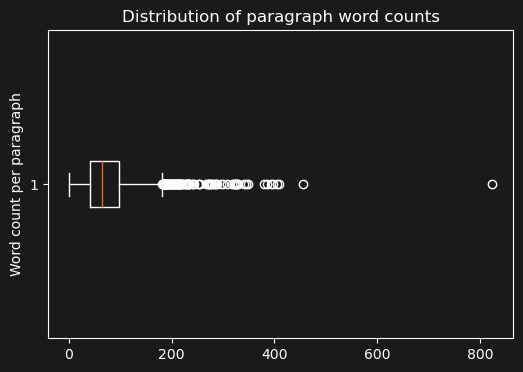

In [12]:
import matplotlib.pyplot as plt

# Descriptive statistics
word_count_stats = source_ef_sudeste_pilot_paragraph_df["word_count"].describe()
display(word_count_stats)

# Boxplot of word counts
plt.figure(figsize=(6, 4))
plt.boxplot(source_ef_sudeste_pilot_paragraph_df["word_count"], vert=False)
plt.ylabel("Word count per paragraph")
plt.title("Distribution of paragraph word counts")
plt.show()

# Outliers

In [14]:
import numpy as np

wc = source_ef_sudeste_pilot_paragraph_df["word_count"]

q1 = wc.quantile(0.25)
q3 = wc.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (wc < lower_bound) | (wc > upper_bound)
n_outliers = outlier_mask.sum()

total_paragraphs = len(source_ef_sudeste_pilot_paragraph_df)

print(f"Total paragraphs: {total_paragraphs}")
print(f"IQR-based lower bound: {lower_bound:.2f}")
print(f"IQR-based upper bound: {upper_bound:.2f}")
print(f"Number of outlier paragraphs: {n_outliers}")
print(f"Percentage of outliers: {n_outliers / total_paragraphs * 100:.2f}%")

Total paragraphs: 2394
IQR-based lower bound: -41.62
IQR-based upper bound: 181.38
Number of outlier paragraphs: 106
Percentage of outliers: 4.43%


# Label paragraph word-count outliers

In [15]:
# Add a boolean outlier flag based on the IQR bounds
source_ef_sudeste_pilot_paragraph_df["outlier"] = (
        (source_ef_sudeste_pilot_paragraph_df["word_count"] < lower_bound) |
        (source_ef_sudeste_pilot_paragraph_df["word_count"] > upper_bound)
)

source_ef_sudeste_pilot_paragraph_df["outlier"].value_counts()

outlier
False    2288
True      106
Name: count, dtype: int64

In [16]:
source_ef_sudeste_pilot_paragraph_df

,filename,state,paragraph_index,filename_paragraph,word_count,outlier
0,es_ef_anos_finais_ciencias_da_natureza.txt,es,1,es_ef_anos_finais_ciencias_da_natureza_p1.txt,79,False
1,es_ef_anos_finais_ciencias_da_natureza.txt,es,2,es_ef_anos_finais_ciencias_da_natureza_p2.txt,66,False
2,es_ef_anos_finais_ciencias_da_natureza.txt,es,3,es_ef_anos_finais_ciencias_da_natureza_p3.txt,97,False
3,es_ef_anos_finais_linguagens_ingles_1.txt,es,1,es_ef_anos_finais_linguagens_ingles_1_p1.txt,56,False
4,es_ef_anos_finais_linguagens_ingles_1.txt,es,2,es_ef_anos_finais_linguagens_ingles_1_p2.txt,65,False
...,...,...,...,...,...,...
2389,sp_inf_e_ef_intro_9.txt,sp,3,sp_inf_e_ef_intro_9_p3.txt,49,False
2390,sp_inf_e_ef_intro_9.txt,sp,4,sp_inf_e_ef_intro_9_p4.txt,46,False
2391,sp_inf_e_ef_intro_9.txt,sp,5,sp_inf_e_ef_intro_9_p5.txt,113,False
2392,sp_inf_e_ef_intro_9.txt,sp,6,sp_inf_e_ef_intro_9_p6.txt,55,False


# Export paragraph-level data to NDJSON

In [17]:
output_path = "corpus/source_ef_sudeste_pilot_paragraph.ndjson"

source_ef_sudeste_pilot_paragraph_df.to_json(
    output_path,
    orient="records",
    lines=True,
    force_ascii=False
)

output_path

'corpus/source_ef_sudeste_pilot_paragraph.ndjson'